# Bank Customer Churn Prediction using Machine Learning

## Introduction

Customer churn is one of the most pressing challenges facing the banking industry today. 
When a customer closes their account or switches to a competitor, the bank loses not just 
immediate revenue but also the lifetime value that customer represented. Studies show that 
acquiring a new customer costs 5 to 7 times more than retaining an existing one — making 
early churn detection a high-priority business problem.

This project develops a machine learning–based classification system to predict whether 
a bank customer is likely to exit, using demographic and account-level data from 10,000 
customers across France, Germany, and Spain. Three models — Logistic Regression, 
Decision Tree, and Random Forest — are trained and compared to determine the most 
reliable predictor, enabling banks to take proactive retention action before a customer 
is lost.

### Key Objectives
- Analyse patterns between customer attributes and churn behaviour
- Preprocess and encode categorical features for model compatibility
- Train and evaluate multiple classification algorithms
- Select the best-performing model based on accuracy and classification metrics
- Deploy the final model for real-time churn prediction

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pickle, os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')
os.makedirs('models', exist_ok=True)

In [2]:
df = pd.read_csv('Churn_Modelling.csv')

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

## EDA

In [5]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [7]:
print(f"\nChurn Rate: {df['Exited'].mean()*100:.1f}%")


Churn Rate: 20.4%


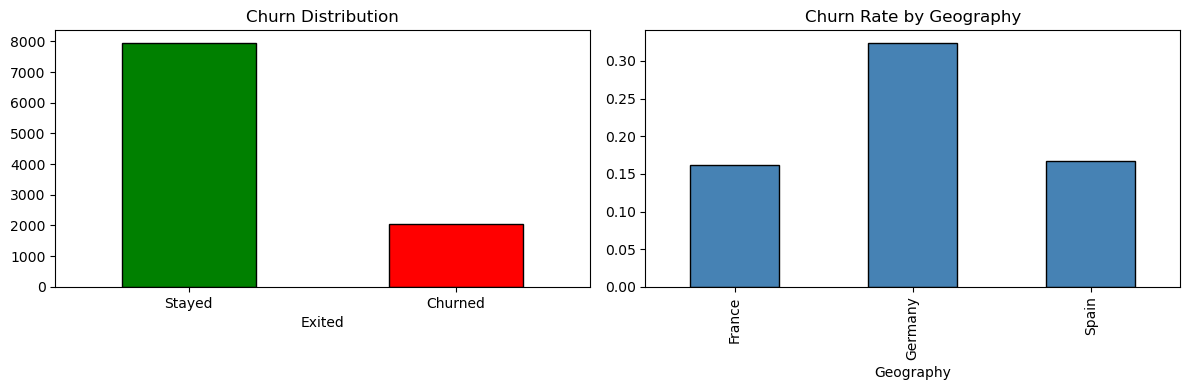

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Exited'].value_counts().plot.bar(ax=axes[0], color=['green','red'], edgecolor='black')
axes[0].set_title('Churn Distribution')
axes[0].set_xticklabels(['Stayed', 'Churned'], rotation=0)
df.groupby('Geography')['Exited'].mean().plot.bar(ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Churn Rate by Geography')
plt.tight_layout()
plt.show()

## Age vs Churn

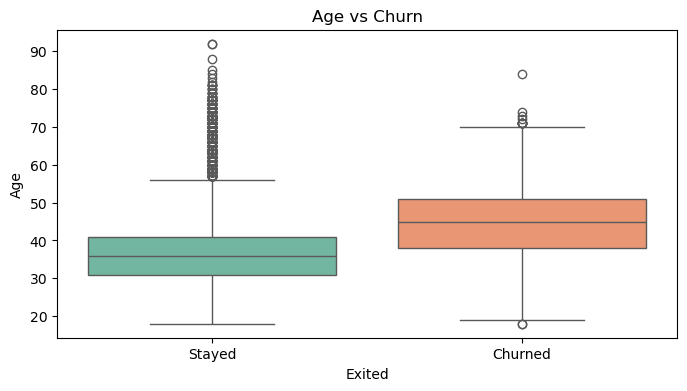

In [9]:
plt.figure(figsize=(8,4))
sns.boxplot(x='Exited', y='Age', data=df, palette='Set2')
plt.title('Age vs Churn')
plt.xticks([0,1], ['Stayed', 'Churned'])
plt.show()

## Correlation Heatmap

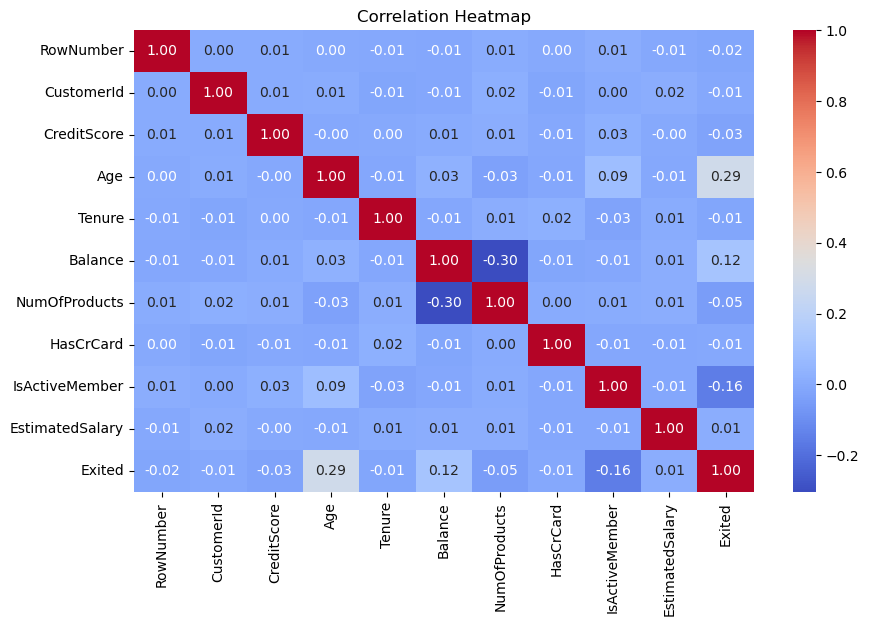

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## Geography/Gender churn breakdown

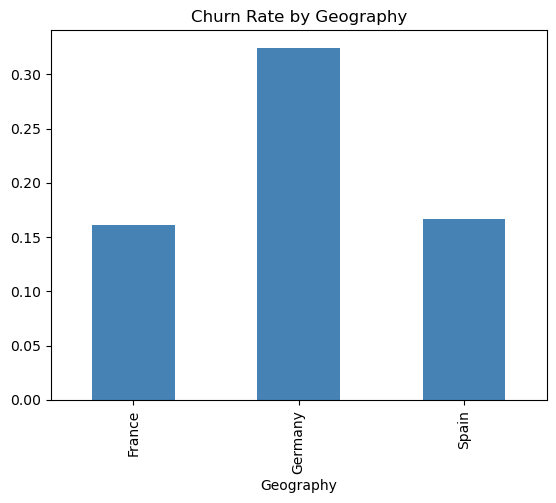

In [11]:
df.groupby('Geography')['Exited'].mean().plot.bar(color='steelblue')
plt.title("Churn Rate by Geography")
plt.show()

## PREPROCESSING

In [12]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

le_geo = LabelEncoder()
le_gen = LabelEncoder()
df['Geography'] = le_geo.fit_transform(df['Geography'])
df['Gender']    = le_gen.fit_transform(df['Gender'])

## Save encoders

In [13]:
pickle.dump(le_geo, open('models/le_geo.pkl', 'wb'))
pickle.dump(le_gen, open('models/le_gen.pkl', 'wb'))

print("Geography classes:", le_geo.classes_)   # 0=France, 1=Germany, 2=Spain
print("Gender classes:", le_gen.classes_)       # 0=Female, 1=Male

Geography classes: ['France' 'Germany' 'Spain']
Gender classes: ['Female' 'Male']


## FEATURE SELECTION & SPLIT

In [14]:
X = df.drop('Exited', axis=1)
y = df['Exited']
feature_names = X.columns.tolist()

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [17]:
pickle.dump(scaler, open('models/scaler.pkl', 'wb'))
pickle.dump(feature_names, open('models/feature_names.pkl', 'wb'))
print("Features:", feature_names)

Features: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


## TRAIN & EVALUATE FUNCTION

In [18]:
def train_and_evaluate(model, X_tr, y_tr, X_te, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:,1]

    acc = accuracy_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob)

    print(f"\n{'='*50}\n  {name}\n  Accuracy: {acc:.4f}  |  ROC-AUC: {auc:.4f}\n{'='*50}")
    print(classification_report(y_te, y_pred))

    cm = confusion_matrix(y_te, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Stay','Churn']).plot(cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

    return acc, auc

## TRAIN ALL MODELS


  Logistic Regression
  Accuracy: 0.8050  |  ROC-AUC: 0.7710
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.14      0.23       407

    accuracy                           0.81      2000
   macro avg       0.70      0.56      0.56      2000
weighted avg       0.77      0.81      0.75      2000



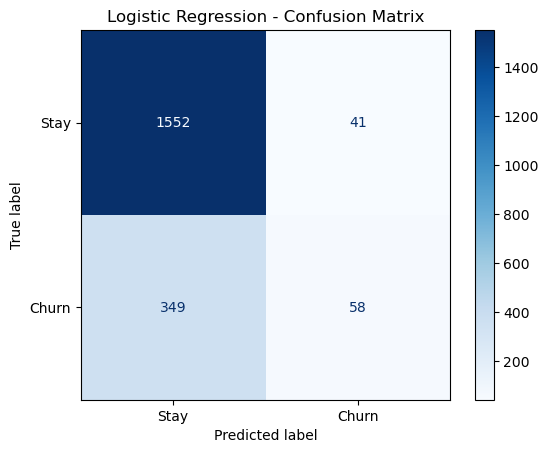


  Decision Tree
  Accuracy: 0.7755  |  ROC-AUC: 0.6643
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      1593
           1       0.45      0.48      0.46       407

    accuracy                           0.78      2000
   macro avg       0.66      0.66      0.66      2000
weighted avg       0.78      0.78      0.78      2000



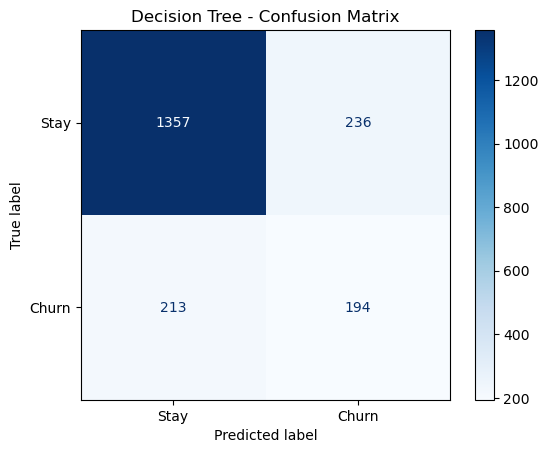


  Random Forest
  Accuracy: 0.8645  |  ROC-AUC: 0.8469
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000



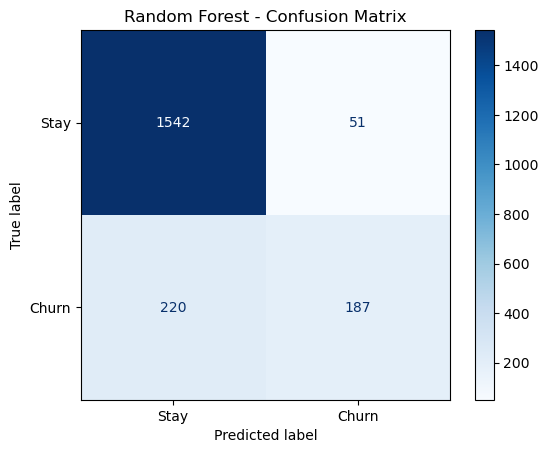

In [19]:
logreg = LogisticRegression()
lr_acc, lr_auc = train_and_evaluate(logreg, X_train_scaled, y_train, X_test_scaled, y_test, "Logistic Regression")

dt = DecisionTreeClassifier(random_state=42)
dt_acc, dt_auc = train_and_evaluate(dt, X_train_scaled, y_train, X_test_scaled, y_test, "Decision Tree")

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_acc, rf_auc = train_and_evaluate(rf, X_train_scaled, y_train, X_test_scaled, y_test, "Random Forest")

## MODEL COMPARISON PLOT

In [20]:
labels = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accs   = [lr_acc, dt_acc, rf_acc]
aucs   = [lr_auc, dt_auc, rf_auc]

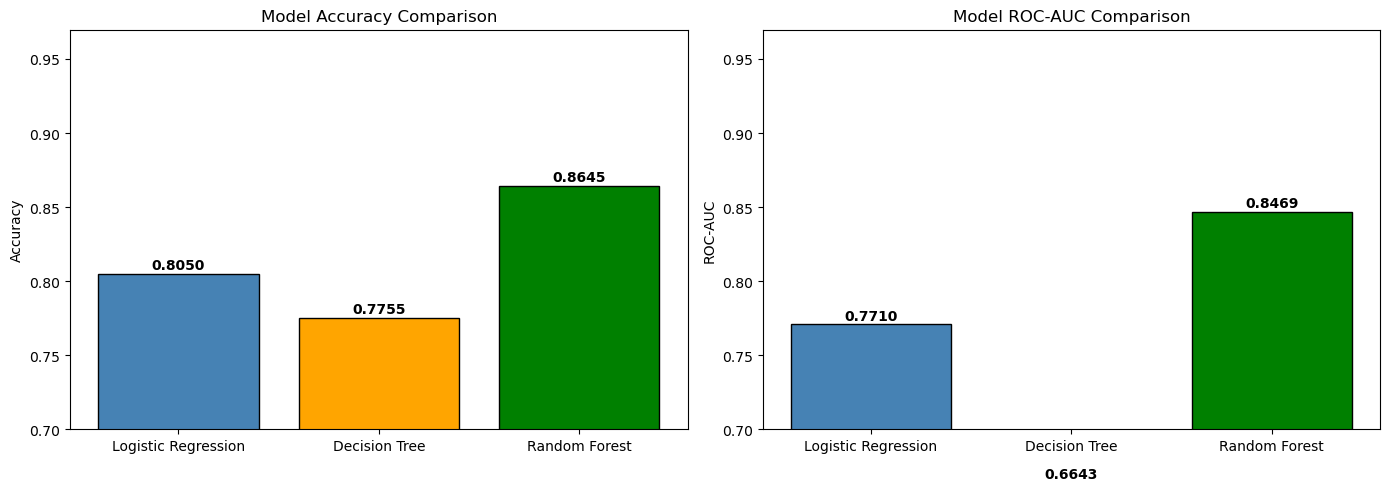

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, vals, title, color in zip(axes, [accs, aucs],
                                   ['Accuracy', 'ROC-AUC'],
                                   [['steelblue','orange','green']]*2):
    bars = ax.bar(labels, vals, color=color, edgecolor='black')
    ax.set_ylim(0.7, 0.97)
    ax.set_title(f'Model {title} Comparison')
    ax.set_ylabel(title)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

##  FEATURE IMPORTANCE

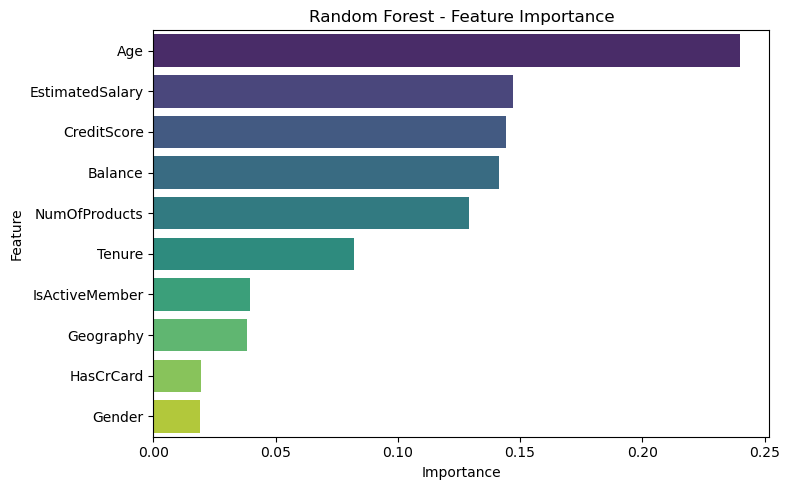

In [22]:
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': rf.feature_importances_})
fi_df = fi_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
plt.title('Random Forest - Feature Importance')
plt.tight_layout()
plt.show()

## SAVE BEST MODEL (Random Forest)

In [23]:
pickle.dump(rf, open('models/best_model.pkl', 'wb'))
print("Model saved! Best Model: Random Forest")
print(f"   Accuracy: {rf_acc:.4f} | ROC-AUC: {rf_auc:.4f}")

Model saved! Best Model: Random Forest
   Accuracy: 0.8645 | ROC-AUC: 0.8469


## Conclusion

This project successfully built and evaluated a machine learning pipeline for 
predicting bank customer churn using real-world customer data.

### Model Performance Summary

| Model               | Accuracy | Churn Recall |
|---------------------|----------|--------------|
| Logistic Regression | 81.5%    | 18%          |
| Decision Tree       | 78.4%    | 52%          |
| **Random Forest**   | **86.6%**| **46%**      |

Random Forest emerged as the best-performing model with 86.6% accuracy, 
demonstrating strong capability in identifying customers who are likely to stay. 
Key drivers of churn identified through this analysis include customer age, 
number of products held, active membership status, and geography — 
with Germany showing notably higher churn rates compared to France and Spain.

### Limitations
- Dataset contains approximately 20% churned customers, creating class imbalance 
  that limits recall for the minority (churned) class
- Predictions are probabilistic and should complement, not replace, 
  relationship manager judgment

### Future Improvements
- Apply SMOTE or class-weight balancing to improve churn recall
- Explore XGBoost and LightGBM for enhanced performance
- Integrate SHAP values for model explainability
- Deploy via Streamlit for real-time business use